# Notebook 08b — GAM with Interactions: Weather Effects on Cycling Demand

## 0. Imports & Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pygam"])


0

In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pygam import LinearGAM, PoissonGAM, s, f, l, te # Generalized Additive Models
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [3]:
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "commute_score", "site_type"]]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  →  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())


Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
commuter    72143
leisure     44342
mixed       27853


## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Based on the IQR audit above, classify each candidate:
- **`remove_dates`** — likely data/sensor errors: set `aantal` to NaN
- **`event_dates`** — confirmed real events: keep value, flag with `is_event_day = 1`

Then apply removals, split into train (2023–2024) / test (2025), and compute the per-station log-mean offset from **train only**.

In [4]:
# ── outlier blacklist (informed by IQR audit above) ───────────────────
remove_dates = [
    (105, '2023-03-03'),  # St. Pieters Leeuw (median=0 station, isolated single-day spike)
    (85,  '2024-07-25'),  # Asse teller 1, 58.8x
    (20,  '2024-06-02'),  # Brugge, 20.1x
    (140, '2024-07-13'),  # Hasselt ring, 20.0x
    (129, '2024-08-12'),  # Lokeren teller 2, 19.1x
    (78,  '2023-07-01'),  # Pepingen, 15.0x
    (50,  '2024-09-18'),  # Brugge Sint-Andries, 11.9x
    (94,  '2023-08-20'),  # Herentals teller 2, 13.2x — no event found (criterium was Jul 27-28)
    (33,  '2023-01-20'),  # Lummen, 7.7x — isolated winter spike, no plausible event
    (81,  '2024-08-18'),  # Wemmel teller 2, 7.5x — isolated single day, no known event
    # Beersel teller 2 — 16-day anomaly, likely temporary detour/rerouting (site 83)
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

# ── known recurring event days (retain value, add flag) ───────────────
event_dates = [
    # Kampenhout — Super 8 Classic annual race (site 70)
    (70,  '2023-09-16'),
    (70,  '2024-09-21'),
    # Asse teller 1 — recurring July events (site 85)
    (85,  '2024-07-07'),
    (85,  '2024-07-21'),
    # Brugge Sint-Andries — May event (sites 72, 51)
    (72,  '2024-05-08'),
    (51,  '2024-05-08'),
    # Maaseik — Ronde van Maaseik (sites 43, 44)
    (43,  '2023-05-28'),
    (44,  '2023-05-28'),
    # Heers — spring cycling season / classics area (sites 28, 34)
    (28,  '2024-04-06'),
    (28,  '2024-04-13'),
    (28,  '2024-04-14'),
    (28,  '2023-04-30'),
    (28,  '2023-05-01'),
    (28,  '2023-05-04'),
    (34,  '2024-04-06'),
    (34,  '2023-04-30'),
    (34,  '2023-06-03'),
    # Genk — recurring late-September event (site 14)
    (14,  '2023-09-24'),
    (14,  '2024-09-22'),
    # As — multi-day event, EK Wielrennen 2024 tourist/spectator effect (site 48)
    (48,  '2024-09-18'),
    (48,  '2024-09-19'),
    (48,  '2024-09-20'),
    (48,  '2024-09-21'),
    (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

# ── verify ─────────────────────────────────────────────────────────────
print('\nVerification — removed rows (aantal → NaN):')
for sid, d in remove_dates:
    row = panel_good[(panel_good['site ID'] == sid) & (panel_good['date'].astype(str).str[:10] == d)]
    status = 'NaN ✓' if row['aantal'].isna().all() else 'NOT removed!'
    naam = row['naam'].iloc[0] if len(row) else '?'
    print(f'  site {sid:<4} {naam[:24]:<24} {d}  →  {status}')
print(f'Event-flagged rows: {panel_good["is_event_day"].sum()}')

# ── train / test split ─────────────────────────────────────────────────
print(f"\n{'─'*40}")
train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

# ── station-level log-mean offset (train only, to avoid data leakage) ─
# mean(log1p(y)) per site: within-centering in log space, consistent with y_adj = log1p(y) - offset
site_log_mean = (
    train.groupby('site ID')['aantal']
    .apply(lambda x: np.log1p(x).mean())
    .reset_index()
    .rename(columns={'aantal': 'site_offset'})
)
train      = train.merge(site_log_mean, on='site ID', how='left')
test       = test.merge(site_log_mean, on='site ID', how='left')
panel_good = panel_good.merge(site_log_mean, on='site ID', how='left')

print(f"Train size : {len(train):,} rows (2023–2024)")
print(f"Test size  : {len(test):,} rows (2025)")
# ── three-way split for lambda tuning ─────────────────────────────────
train_2023 = panel_good[panel_good["date"].dt.year == 2023].copy()
valid_2024 = panel_good[panel_good["date"].dt.year == 2024].copy()

# offset from 2023 only — use map() to overwrite the existing site_offset column
# (panel_good already carries the 2023-2024 offset from the merge above)
site_offset_2023 = (
    train_2023.groupby('site ID')['aantal']
    .apply(lambda x: np.log1p(x).mean())
)
train_2023['site_offset'] = train_2023['site ID'].map(site_offset_2023)
valid_2024['site_offset'] = valid_2024['site ID'].map(site_offset_2023)

print(f"Tuning split — train_2023: {len(train_2023):,} rows | valid_2024: {len(valid_2024):,} rows")


Removed 26 extreme outlier rows
Flagged 24 recurring event days

Verification — removed rows (aantal → NaN):
  site 105  St. pieters leeuw teller 2023-03-03  →  NaN ✓
  site 85   Asse teller 1            2024-07-25  →  NaN ✓
  site 20   Brugge                   2024-06-02  →  NaN ✓
  site 140  Hasselt ring             2024-07-13  →  NaN ✓
  site 129  Lokeren teller 2         2024-08-12  →  NaN ✓
  site 78   Pepingen teller 1        2023-07-01  →  NaN ✓
  site 50   Brugge, Sint-Andries     2024-09-18  →  NaN ✓
  site 94   Herentals teller 2       2023-08-20  →  NaN ✓
  site 33   Lummen                   2023-01-20  →  NaN ✓
  site 81   Wemmel teller 2          2024-08-18  →  NaN ✓
  site 83   Beersel teller 2         2024-03-19  →  NaN ✓
  site 83   Beersel teller 2         2024-03-27  →  NaN ✓
  site 83   Beersel teller 2         2024-03-28  →  NaN ✓
  site 83   Beersel teller 2         2024-03-29  →  NaN ✓
  site 83   Beersel teller 2         2024-03-30  →  NaN ✓
  site 83   Beersel t

## 1. Feature Engineering

In [5]:
# Encode boolean features as integers for modeling
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek",          # 8
    "month",              # 9
    "is_weekend",         # 10
    "is_public_holiday",  # 11
    "is_school_holiday",  # 12
    "is_event_day",       # 13
    "commute_score",      # 14
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Train shape: {train.shape} |  Test shape: {test.shape}")

Features (15): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'commute_score']
Train shape: (96187, 58) |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

In [6]:
from sklearn.preprocessing import StandardScaler
import warnings

def make_X_y_with_offset(df, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df[cols].dropna()
    X     = df_clean[features].values
    y_raw = df_clean["aantal"].values.astype(float)
    y_log = np.log1p(y_raw) # log-transform the target to stabilize variance and handle skewness
    y_adj = y_log - df_clean["site_offset"].values
    return X, y_adj, y_raw, df_clean.index

# Sort by date so TimeSeriesSplit in lambda search respects temporal ordering
train = train.sort_values("date").reset_index(drop=True)
test  = test.sort_values("date").reset_index(drop=True)

X_train, y_train_adj, y_train_raw, _ = make_X_y_with_offset(train, ALL_FEATURES)
X_test,  y_test_adj,  y_test_raw,  _ = make_X_y_with_offset(test,  ALL_FEATURES)

continuous_idx = list(range(8)) + [14]  # indices 0-7: continuous weather features; 14: commute_score
scaler = StandardScaler()
X_train_s = X_train.copy().astype(float)
X_test_s  = X_test.copy().astype(float)
X_train_s[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_test_s[:,  continuous_idx] = scaler.transform(X_test[:,  continuous_idx])

print(f"X_train : {X_train_s.shape}  |  y_train : {y_train_adj.shape}")
print(f"X_test  : {X_test_s.shape}   |  y_test  : {y_test_adj.shape}")
print(f"y_train_raw — mean: {y_train_raw.mean():.1f}, std: {y_train_raw.std():.1f}, "
      f"min: {y_train_raw.min():.0f}, max: {y_train_raw.max():.0f}")
# ── feature matrices for tuning split (2023 train / 2024 valid) ───────
train_2023 = train_2023.sort_values("date").reset_index(drop=True)
valid_2024 = valid_2024.sort_values("date").reset_index(drop=True)

X_train23, y_train23_adj, y_train23_raw, _ = make_X_y_with_offset(train_2023, ALL_FEATURES)
X_valid24,  y_valid24_adj, y_valid24_raw,  _ = make_X_y_with_offset(valid_2024,  ALL_FEATURES)

scaler_tune = StandardScaler()
X_train23_s = X_train23.copy().astype(float)
X_valid24_s  = X_valid24.copy().astype(float)
X_train23_s[:, continuous_idx] = scaler_tune.fit_transform(X_train23[:, continuous_idx])
X_valid24_s[:,  continuous_idx] = scaler_tune.transform(X_valid24[:,  continuous_idx])

print(f"X_train23: {X_train23_s.shape}  |  X_valid24: {X_valid24_s.shape}")


X_train : (95400, 15)  |  y_train : (95400,)
X_test  : (47842, 15)   |  y_test  : (47842,)
y_train_raw — mean: 484.2, std: 633.6, min: 0, max: 10109
X_train23: (47345, 15)  |  X_valid24: (48055, 15)


## 3. Model A — Full GAM (all stations)
Feature index mapping:
- 0: temp_avg → s()  
- 1: precip_total → s()  
- 2: wind_avg → s()  
- 3: sunshine_min → s()  
- 4: humidity_avg → s()  
- 5: temp_avg_lag1 → s()  
- 6: precip_total_lag1 → s()  
- 7: wind_avg_lag1 → s()  
- 8: dayofweek → f() (factor: captures all day-of-week effects)
- 9: month → f() (factor: avoids spline boundary distortion at Jan/Dec)
- 10: is_weekend → l()
- 11: is_public_holiday → l()  
- 12: is_school_holiday → l()  
- 13: is_event_day → l()  
- 14: commute_score → l()  

Interaction terms (tensor product smooths via `te()`):
- te(1, 14): precip_total × commute_score
- te(3, 14): sunshine_min × commute_score
- te(0, 10): temp_avg × is_weekend
- te(1, 10): precip_total × is_weekend
- te(2, 14): wind_avg × commute_score
- te(0, 14): temp_avg × commute_score

No site_idx — replaced by per-station log-mean offset.

In [7]:
LAM_GRID  = [0.1, 1, 10, 100, 1000]
N_SPLINES = 10

def val_lam_search(gam_factory, X_tr, y_tr, X_val, val_df, features, lam_grid=LAM_GRID):
    """Select lambda by evaluating MAE on the 2024 validation year.
    Returns (best_lam, best_val_mae)."""
    best_lam, best_mae = lam_grid[0], np.inf
    for lam in lam_grid:
        g = gam_factory()
        g.set_params(lam=lam)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            g.fit(X_tr, y_tr)
        y_pred = predict_original_scale(g, X_val, val_df, features)
        cols   = features + ["aantal", "site_offset"]
        y_true = val_df[cols].dropna()["aantal"].values
        mae    = mean_absolute_error(y_true, y_pred)
        print(f"  lam={lam:>6}: val MAE={mae:.1f}")
        if mae < best_mae:
            best_mae, best_lam = mae, lam
    print(f"\u2192 Best lam: {best_lam}  (val MAE={best_mae:.1f})")
    return best_lam, best_mae


In [8]:
def predict_original_scale(gam, X_scaled, df_subset, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df_subset[cols].dropna()
    offset   = df_clean["site_offset"].values
    y_adj_pred = gam.predict(X_scaled)
    return np.clip(np.expm1(y_adj_pred + offset), 0, None)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R\u00b2={r2:.3f}")
    return mae, rmse, r2

def make_full_gam():
    return LinearGAM(
        s(0, n_splines=N_SPLINES) +  # temp_avg
        s(1, n_splines=N_SPLINES) +  # precip_total
        s(2, n_splines=N_SPLINES) +  # wind_avg
        s(3, n_splines=N_SPLINES) +  # sunshine_min
        s(4, n_splines=N_SPLINES) +  # humidity_avg
        s(5, n_splines=N_SPLINES) +  # temp_avg_lag1
        s(6, n_splines=N_SPLINES) +  # precip_total_lag1
        s(7, n_splines=N_SPLINES) +  # wind_avg_lag1
        f(8)               +  # dayofweek
        f(9)               +  # month
        l(10)              +  # is_weekend
        l(11)              +  # is_public_holiday
        l(12)              +  # is_school_holiday
        l(13)              +  # is_event_day
        l(14) +               # commute_score
        te(1, 14) +   # precip_total × commute_score
        te(3, 14) +   # sunshine_min × commute_score
        te(0, 10) +   # temp_avg    × is_weekend
        te(1, 10) +   # precip_total × is_weekend
        te(2, 14) +   # wind_avg    × commute_score
        te(0, 14),    # temp_avg    × commute_score
        max_iter=200
    )

# ── lam selection on 2024 validation ──────────────────────────────────
print("Full GAM \u2014 lam search on 2024 validation:")
best_lam_full, _ = val_lam_search(make_full_gam, X_train23_s, y_train23_adj,
                                   X_valid24_s, valid_2024, ALL_FEATURES)

# ── val metrics with best lam (model trained on 2023 only) ────────────
g_val_full = make_full_gam()
g_val_full.set_params(lam=best_lam_full)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    g_val_full.fit(X_train23_s, y_train23_adj)
y_pred_val_full = predict_original_scale(g_val_full, X_valid24_s, valid_2024, ALL_FEATURES)
y_val24_raw = valid_2024[ALL_FEATURES + ["aantal", "site_offset"]].dropna()["aantal"].values

# ── final model: retrain on full 2023\u20132024, test on 2025 ───────────
gam_full = make_full_gam()
gam_full.set_params(lam=best_lam_full)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_full.fit(X_train_s, y_train_adj)
y_pred_test_full = predict_original_scale(gam_full, X_test_s, test, ALL_FEATURES)

print("\n" + "=" * 52)
print("MODEL A \u2014 Full GAM Performance")
print("=" * 52)
val_mae_full,  val_rmse_full,  val_r2_full  = evaluate(y_val24_raw,  y_pred_val_full,  "Val 2024")
test_mae_full, test_rmse_full, test_r2_full = evaluate(y_test_raw,   y_pred_test_full, "Test 2025")
print("=" * 52)


Full GAM — lam search on 2024 validation:
  lam=   0.1: val MAE=132.6
  lam=     1: val MAE=122.0
  lam=    10: val MAE=119.7
  lam=   100: val MAE=120.1
  lam=  1000: val MAE=121.4
→ Best lam: 10  (val MAE=119.7)

MODEL A — Full GAM Performance
  Val 2024    : MAE=119.7  RMSE=282.1  R²=0.804
  Test 2025   : MAE=131.1  RMSE=280.1  R²=0.843


## 4. Model B — Commuter GAM

In [9]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]   == "commuter"].copy()

train_2023_c = train_2023[train_2023["site_type"] == "commuter"].copy()
valid_2024_c = valid_2024[valid_2024["site_type"] == "commuter"].copy()

X_train_c, y_train_c_adj, y_train_c_raw, _ = make_X_y_with_offset(train_c, ALL_FEATURES)
X_test_c,  y_test_c_adj,  y_test_c_raw,  _ = make_X_y_with_offset(test_c,  ALL_FEATURES)

scaler_c = StandardScaler()
X_train_cs = X_train_c.copy().astype(float)
X_test_cs  = X_test_c.copy().astype(float)
X_train_cs[:, continuous_idx] = scaler_c.fit_transform(X_train_c[:, continuous_idx])
X_test_cs[:,  continuous_idx] = scaler_c.transform(X_test_c[:,  continuous_idx])

X_train23_c, y_train23_c_adj, _, _ = make_X_y_with_offset(train_2023_c, ALL_FEATURES)
X_valid24_c,  _,               _, _ = make_X_y_with_offset(valid_2024_c,  ALL_FEATURES)

scaler_c_tune = StandardScaler()
X_train23_cs = X_train23_c.copy().astype(float)
X_valid24_cs  = X_valid24_c.copy().astype(float)
X_train23_cs[:, continuous_idx] = scaler_c_tune.fit_transform(X_train23_c[:, continuous_idx])
X_valid24_cs[:,  continuous_idx] = scaler_c_tune.transform(X_valid24_c[:,  continuous_idx])

def make_commuter_gam():
    return LinearGAM(
        s(0, n_splines=N_SPLINES) + s(1, n_splines=N_SPLINES) + s(2, n_splines=N_SPLINES) +
        s(3, n_splines=N_SPLINES) + s(4, n_splines=N_SPLINES) + s(5, n_splines=N_SPLINES) +
        s(6, n_splines=N_SPLINES) + s(7, n_splines=N_SPLINES) + f(8) +
        f(9)                       + l(10) + l(11) + l(12) + l(13) + l(14) +
        te(1, 14) +   # precip_total × commute_score
        te(3, 14) +   # sunshine_min × commute_score
        te(0, 10) +   # temp_avg    × is_weekend
        te(1, 10) +   # precip_total × is_weekend
        te(2, 14) +   # wind_avg    × commute_score
        te(0, 14),    # temp_avg    × commute_score
        max_iter=200
    )

print("Commuter GAM \u2014 lam search on 2024 validation:")
best_lam_c, _ = val_lam_search(make_commuter_gam, X_train23_cs, y_train23_c_adj,
                                X_valid24_cs, valid_2024_c, ALL_FEATURES)

g_val_c = make_commuter_gam()
g_val_c.set_params(lam=best_lam_c)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    g_val_c.fit(X_train23_cs, y_train23_c_adj)
y_pred_val_c = predict_original_scale(g_val_c, X_valid24_cs, valid_2024_c, ALL_FEATURES)
y_val24_c_raw = valid_2024_c[ALL_FEATURES + ["aantal", "site_offset"]].dropna()["aantal"].values

gam_commuter = make_commuter_gam()
gam_commuter.set_params(lam=best_lam_c)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_commuter.fit(X_train_cs, y_train_c_adj)
y_pred_c = predict_original_scale(gam_commuter, X_test_cs, test_c, ALL_FEATURES)

print("Commuter GAM:")
val_mae_c,  val_rmse_c,  val_r2_c  = evaluate(y_val24_c_raw, y_pred_val_c, "Val 2024")
mae_c,      rmse_c,      r2_c      = evaluate(y_test_c_raw,  y_pred_c,     "Test 2025")


Commuter GAM — lam search on 2024 validation:
  lam=   0.1: val MAE=109.5
  lam=     1: val MAE=103.0
  lam=    10: val MAE=101.6
  lam=   100: val MAE=101.2
  lam=  1000: val MAE=103.0
→ Best lam: 100  (val MAE=101.2)
Commuter GAM:
  Val 2024    : MAE=101.2  RMSE=199.4  R²=0.913
  Test 2025   : MAE=118.3  RMSE=241.0  R²=0.908


## 5. Model C — Leisure GAM

In [10]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]   == "leisure"].copy()

train_2023_l = train_2023[train_2023["site_type"] == "leisure"].copy()
valid_2024_l = valid_2024[valid_2024["site_type"] == "leisure"].copy()

X_train_l, y_train_l_adj, y_train_l_raw, _ = make_X_y_with_offset(train_l, ALL_FEATURES)
X_test_l,  y_test_l_adj,  y_test_l_raw,  _ = make_X_y_with_offset(test_l,  ALL_FEATURES)

scaler_l = StandardScaler()
X_train_ls = X_train_l.copy().astype(float)
X_test_ls  = X_test_l.copy().astype(float)
X_train_ls[:, continuous_idx] = scaler_l.fit_transform(X_train_l[:, continuous_idx])
X_test_ls[:,  continuous_idx] = scaler_l.transform(X_test_l[:,  continuous_idx])

X_train23_l, y_train23_l_adj, _, _ = make_X_y_with_offset(train_2023_l, ALL_FEATURES)
X_valid24_l,  _,               _, _ = make_X_y_with_offset(valid_2024_l,  ALL_FEATURES)

scaler_l_tune = StandardScaler()
X_train23_ls = X_train23_l.copy().astype(float)
X_valid24_ls  = X_valid24_l.copy().astype(float)
X_train23_ls[:, continuous_idx] = scaler_l_tune.fit_transform(X_train23_l[:, continuous_idx])
X_valid24_ls[:,  continuous_idx] = scaler_l_tune.transform(X_valid24_l[:,  continuous_idx])

def make_leisure_gam():
    return LinearGAM(
        s(0, n_splines=N_SPLINES) + s(1, n_splines=N_SPLINES) + s(2, n_splines=N_SPLINES) +
        s(3, n_splines=N_SPLINES) + s(4, n_splines=N_SPLINES) + s(5, n_splines=N_SPLINES) +
        s(6, n_splines=N_SPLINES) + s(7, n_splines=N_SPLINES) + f(8) +
        f(9)                       + l(10) + l(11) + l(12) + l(13) + l(14) +
        te(1, 14) +   # precip_total × commute_score
        te(3, 14) +   # sunshine_min × commute_score
        te(0, 10) +   # temp_avg    × is_weekend
        te(1, 10) +   # precip_total × is_weekend
        te(2, 14) +   # wind_avg    × commute_score
        te(0, 14),    # temp_avg    × commute_score
        max_iter=200
    )

print("Leisure GAM \u2014 lam search on 2024 validation:")
best_lam_l, _ = val_lam_search(make_leisure_gam, X_train23_ls, y_train23_l_adj,
                                X_valid24_ls, valid_2024_l, ALL_FEATURES)

g_val_l = make_leisure_gam()
g_val_l.set_params(lam=best_lam_l)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    g_val_l.fit(X_train23_ls, y_train23_l_adj)
y_pred_val_l = predict_original_scale(g_val_l, X_valid24_ls, valid_2024_l, ALL_FEATURES)
y_val24_l_raw = valid_2024_l[ALL_FEATURES + ["aantal", "site_offset"]].dropna()["aantal"].values

gam_leisure = make_leisure_gam()
gam_leisure.set_params(lam=best_lam_l)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_leisure.fit(X_train_ls, y_train_l_adj)
y_pred_l = predict_original_scale(gam_leisure, X_test_ls, test_l, ALL_FEATURES)

print("Leisure GAM:")
val_mae_l,  val_rmse_l,  val_r2_l  = evaluate(y_val24_l_raw, y_pred_val_l, "Val 2024")
mae_l,      rmse_l,      r2_l      = evaluate(y_test_l_raw,  y_pred_l,     "Test 2025")


Leisure GAM — lam search on 2024 validation:
  lam=   0.1: val MAE=144.9
  lam=     1: val MAE=139.7
  lam=    10: val MAE=140.2
  lam=   100: val MAE=141.0
  lam=  1000: val MAE=143.1
→ Best lam: 1  (val MAE=139.7)
Leisure GAM:
  Val 2024    : MAE=139.7  RMSE=363.6  R²=0.653
  Test 2025   : MAE=143.6  RMSE=329.2  R²=0.717


## 6. Model D — Mixed GAM

In [11]:
train_m = train[train["site_type"] == "mixed"].copy()
test_m  = test[test["site_type"]   == "mixed"].copy()

train_2023_m = train_2023[train_2023["site_type"] == "mixed"].copy()
valid_2024_m = valid_2024[valid_2024["site_type"] == "mixed"].copy()

X_train_m, y_train_m_adj, y_train_m_raw, _ = make_X_y_with_offset(train_m, ALL_FEATURES)
X_test_m,  y_test_m_adj,  y_test_m_raw,  _ = make_X_y_with_offset(test_m,  ALL_FEATURES)

scaler_m = StandardScaler()
X_train_ms = X_train_m.copy().astype(float)
X_test_ms  = X_test_m.copy().astype(float)
X_train_ms[:, continuous_idx] = scaler_m.fit_transform(X_train_m[:, continuous_idx])
X_test_ms[:,  continuous_idx] = scaler_m.transform(X_test_m[:,  continuous_idx])

X_train23_m, y_train23_m_adj, _, _ = make_X_y_with_offset(train_2023_m, ALL_FEATURES)
X_valid24_m,  _,               _, _ = make_X_y_with_offset(valid_2024_m,  ALL_FEATURES)

scaler_m_tune = StandardScaler()
X_train23_ms = X_train23_m.copy().astype(float)
X_valid24_ms  = X_valid24_m.copy().astype(float)
X_train23_ms[:, continuous_idx] = scaler_m_tune.fit_transform(X_train23_m[:, continuous_idx])
X_valid24_ms[:,  continuous_idx] = scaler_m_tune.transform(X_valid24_m[:,  continuous_idx])

def make_mixed_gam():
    return LinearGAM(
        s(0, n_splines=N_SPLINES) + s(1, n_splines=N_SPLINES) + s(2, n_splines=N_SPLINES) +
        s(3, n_splines=N_SPLINES) + s(4, n_splines=N_SPLINES) + s(5, n_splines=N_SPLINES) +
        s(6, n_splines=N_SPLINES) + s(7, n_splines=N_SPLINES) + f(8) +
        f(9)                       + l(10) + l(11) + l(12) + l(13) + l(14) +
        te(1, 14) +   # precip_total × commute_score
        te(3, 14) +   # sunshine_min × commute_score
        te(0, 10) +   # temp_avg    × is_weekend
        te(1, 10) +   # precip_total × is_weekend
        te(2, 14) +   # wind_avg    × commute_score
        te(0, 14),    # temp_avg    × commute_score
        max_iter=200
    )

print("Mixed GAM \u2014 lam search on 2024 validation:")
best_lam_m, _ = val_lam_search(make_mixed_gam, X_train23_ms, y_train23_m_adj,
                                X_valid24_ms, valid_2024_m, ALL_FEATURES)

g_val_m = make_mixed_gam()
g_val_m.set_params(lam=best_lam_m)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    g_val_m.fit(X_train23_ms, y_train23_m_adj)
y_pred_val_m = predict_original_scale(g_val_m, X_valid24_ms, valid_2024_m, ALL_FEATURES)
y_val24_m_raw = valid_2024_m[ALL_FEATURES + ["aantal", "site_offset"]].dropna()["aantal"].values

gam_mixed = make_mixed_gam()
gam_mixed.set_params(lam=best_lam_m)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_mixed.fit(X_train_ms, y_train_m_adj)
y_pred_m = predict_original_scale(gam_mixed, X_test_ms, test_m, ALL_FEATURES)

print("Mixed GAM:")
val_mae_m,  val_rmse_m,  val_r2_m  = evaluate(y_val24_m_raw, y_pred_val_m, "Val 2024")
mae_m,      rmse_m,      r2_m      = evaluate(y_test_m_raw,  y_pred_m,     "Test 2025")


Mixed GAM — lam search on 2024 validation:
  lam=   0.1: val MAE=135.0
  lam=     1: val MAE=120.2
  lam=    10: val MAE=119.3
  lam=   100: val MAE=119.6
  lam=  1000: val MAE=122.2
→ Best lam: 10  (val MAE=119.3)
Mixed GAM:
  Val 2024    : MAE=119.3  RMSE=274.8  R²=0.749
  Test 2025   : MAE=123.8  RMSE=247.6  R²=0.806


In [12]:
print("\n" + "=" * 100)
print("MODEL COMPARISON  (tune 2023 \u2192 val 2024 \u2192 test 2025)")
print("=" * 100)
print(f"{'':20} | {'Full GAM_inter':>12} | {'Commuter GAM_inter':>13} | {'Leisure GAM_inter':>12} | {'Mixed GAM_inter':>12}")
print("-" * 100)
print(f"{'Val  MAE  (2024)':<20} | {val_mae_full:>12.1f} | {val_mae_c:>13.1f} | {val_mae_l:>12.1f} | {val_mae_m:>12.1f}")
print(f"{'Val  RMSE (2024)':<20} | {val_rmse_full:>12.1f} | {val_rmse_c:>13.1f} | {val_rmse_l:>12.1f} | {val_rmse_m:>12.1f}")
print(f"{'Val  R\u00b2   (2024)':<20} | {val_r2_full:>12.3f} | {val_r2_c:>13.3f} | {val_r2_l:>12.3f} | {val_r2_m:>12.3f}")
print("-" * 100)
print(f"{'Test MAE  (2025)':<20} | {test_mae_full:>12.1f} | {mae_c:>13.1f} | {mae_l:>12.1f} | {mae_m:>12.1f}")
print(f"{'Test RMSE (2025)':<20} | {test_rmse_full:>12.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f} | {rmse_m:>12.1f}")
print(f"{'Test R\u00b2   (2025)':<20} | {test_r2_full:>12.3f} | {r2_c:>13.3f} | {r2_l:>12.3f} | {r2_m:>12.3f}")
print("=" * 100)
print("Note: Val metrics use model trained on 2023 only; Test metrics use final model trained on 2023-2024.")



MODEL COMPARISON  (tune 2023 → val 2024 → test 2025)
                     | Full GAM_inter | Commuter GAM_inter | Leisure GAM_inter | Mixed GAM_inter
----------------------------------------------------------------------------------------------------
Val  MAE  (2024)     |        119.7 |         101.2 |        139.7 |        119.3
Val  RMSE (2024)     |        282.1 |         199.4 |        363.6 |        274.8
Val  R²   (2024)     |        0.804 |         0.913 |        0.653 |        0.749
----------------------------------------------------------------------------------------------------
Test MAE  (2025)     |        131.1 |         118.3 |        143.6 |        123.8
Test RMSE (2025)     |        280.1 |         241.0 |        329.2 |        247.6
Test R²   (2025)     |        0.843 |         0.908 |        0.717 |        0.806
Note: Val metrics use model trained on 2023 only; Test metrics use final model trained on 2023-2024.


## 7. Partial Dependence Plots

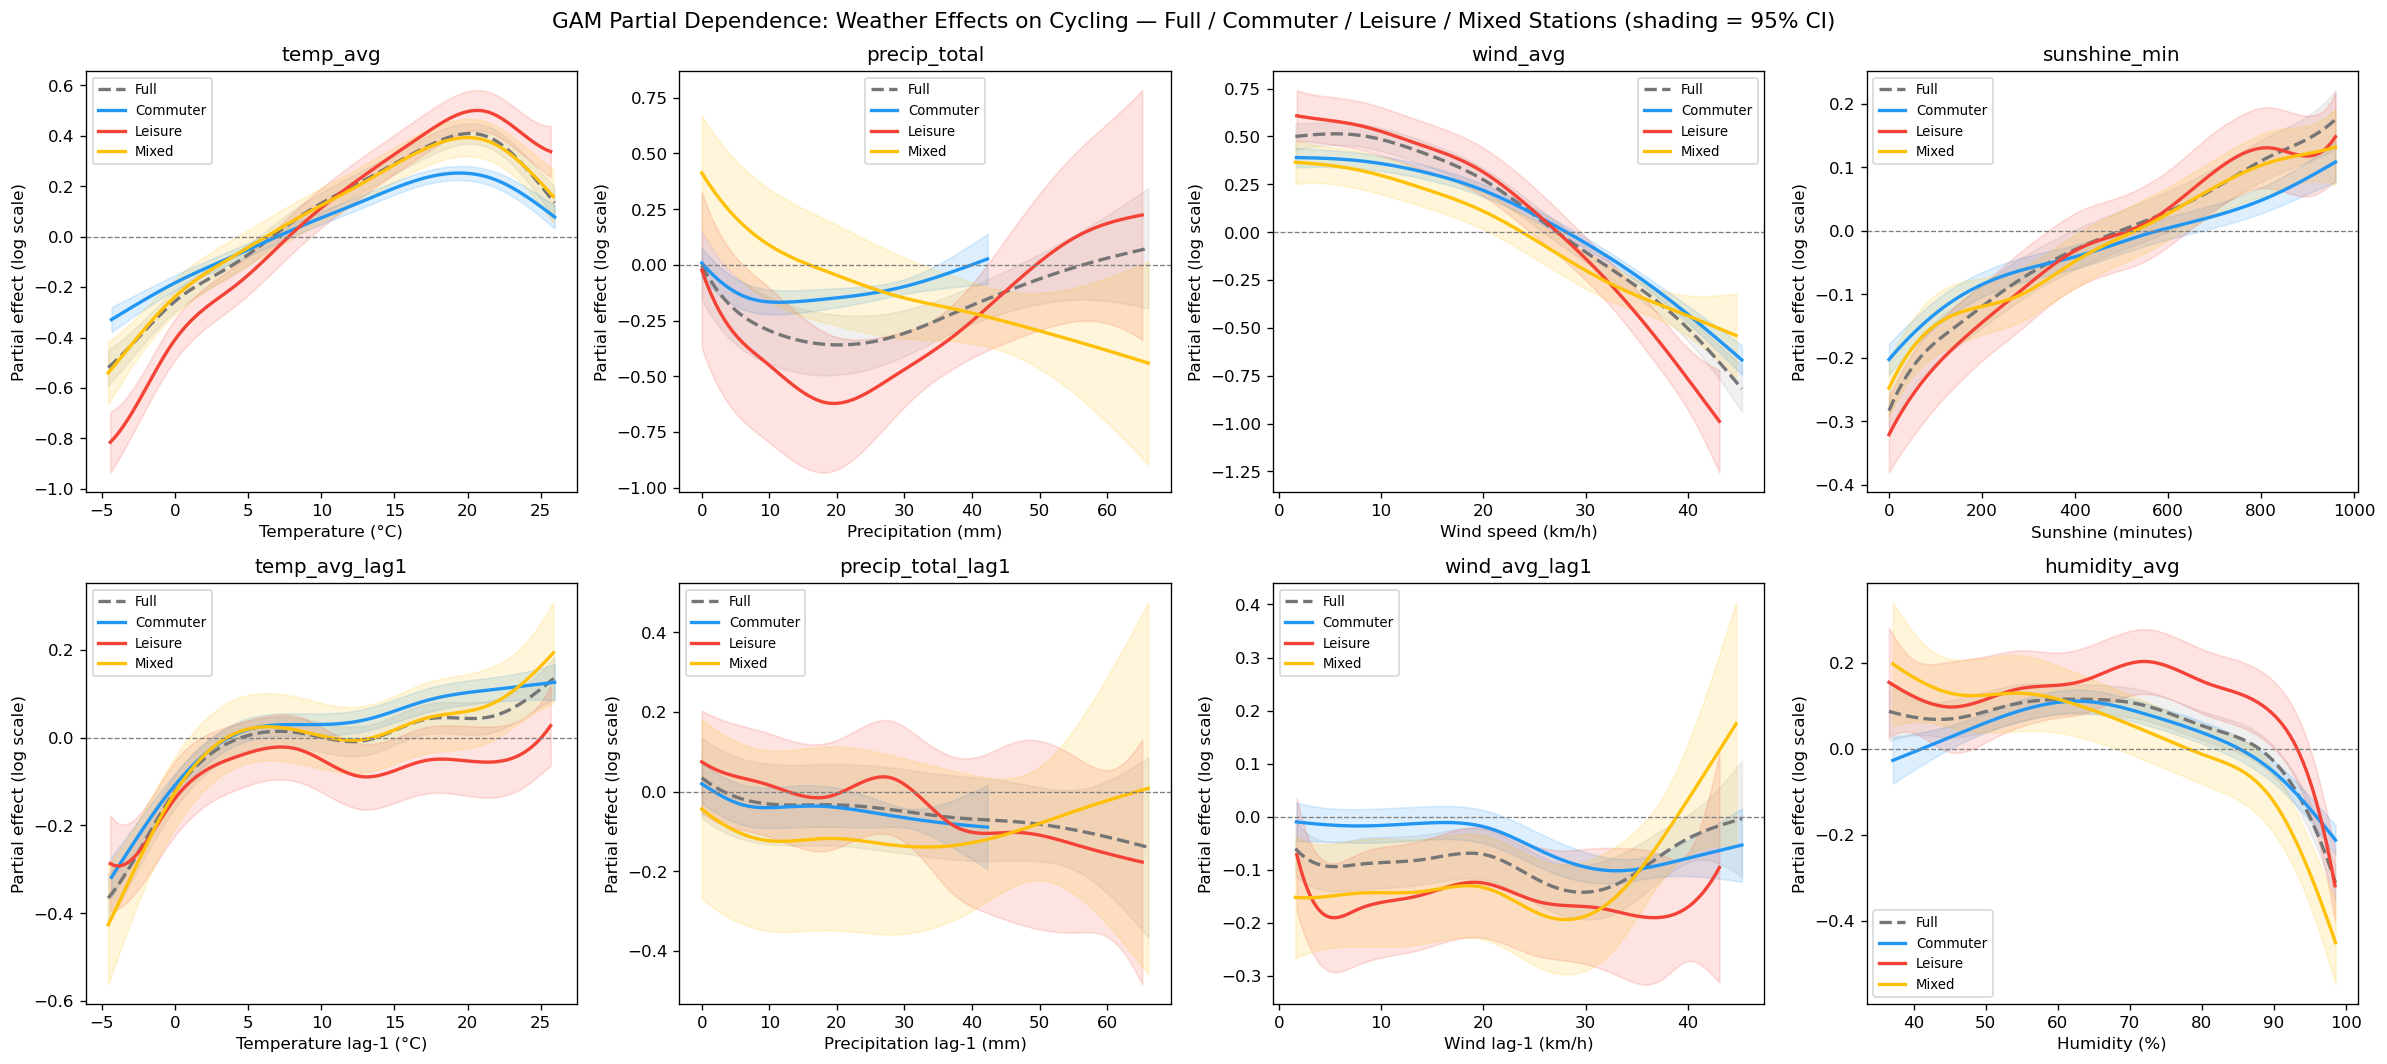

08_gam_partial_dependence saved.


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

COLOR_FULL = "#757575"

weather_terms = [
    (0, "temp_avg",           "Temperature (°C)",        axes[0, 0]),
    (1, "precip_total",       "Precipitation (mm)",       axes[0, 1]),
    (2, "wind_avg",           "Wind speed (km/h)",        axes[0, 2]),
    (3, "sunshine_min",       "Sunshine (minutes)",       axes[0, 3]),
    (5, "temp_avg_lag1",      "Temperature lag-1 (°C)",  axes[1, 0]),
    (6, "precip_total_lag1",  "Precipitation lag-1 (mm)", axes[1, 1]),
    (7, "wind_avg_lag1",      "Wind lag-1 (km/h)",        axes[1, 2]),
    (4, "humidity_avg",       "Humidity (%)",             axes[1, 3]),
]

def inv_x(XX, term_idx, scaler_obj):
    """Inverse-transform one column of a GAM grid back to original units."""
    dummy = np.zeros((len(XX), len(continuous_idx)))
    dummy[:, term_idx] = XX[:, term_idx]
    return scaler_obj.inverse_transform(dummy)[:, term_idx]

MONTH_IDX = ALL_FEATURES.index("month")  # index 9

for term_idx, feat_name, xlabel, ax in weather_terms:
    XX_f = gam_full.generate_X_grid(term=term_idx)
    XX_c = gam_commuter.generate_X_grid(term=term_idx)
    XX_l = gam_leisure.generate_X_grid(term=term_idx)
    XX_m = gam_mixed.generate_X_grid(term=term_idx)

    # generate_X_grid fills non-varied features with 0; fix month (factor, domain 1-12)
    XX_f[:, MONTH_IDX] = 6
    XX_c[:, MONTH_IDX] = 6
    XX_l[:, MONTH_IDX] = 6
    XX_m[:, MONTH_IDX] = 6

    pdep_f, confi_f = gam_full.partial_dependence(term=term_idx, X=XX_f, width=0.95)
    pdep_c, confi_c = gam_commuter.partial_dependence(term=term_idx, X=XX_c, width=0.95)
    pdep_l, confi_l = gam_leisure.partial_dependence(term=term_idx, X=XX_l, width=0.95)
    pdep_m, confi_m = gam_mixed.partial_dependence(term=term_idx, X=XX_m, width=0.95)

    # Convert scaled grid values back to original units for x-axis display
    x_f = inv_x(XX_f, term_idx, scaler)
    x_c = inv_x(XX_c, term_idx, scaler_c)
    x_l = inv_x(XX_l, term_idx, scaler_l)
    x_m = inv_x(XX_m, term_idx, scaler_m)

    ax.plot(x_f, pdep_f, color=COLOR_FULL,         linewidth=2, linestyle="--", label="Full")
    ax.fill_between(x_f, confi_f[:, 0], confi_f[:, 1], alpha=0.10, color=COLOR_FULL)
    ax.plot(x_c, pdep_c, color=COLORS["commuter"], linewidth=2, label="Commuter")
    ax.fill_between(x_c, confi_c[:, 0], confi_c[:, 1], alpha=0.15, color=COLORS["commuter"])
    ax.plot(x_l, pdep_l, color=COLORS["leisure"],  linewidth=2, label="Leisure")
    ax.fill_between(x_l, confi_l[:, 0], confi_l[:, 1], alpha=0.15, color=COLORS["leisure"])
    ax.plot(x_m, pdep_m, color=COLORS["mixed"],    linewidth=2, label="Mixed")
    ax.fill_between(x_m, confi_m[:, 0], confi_m[:, 1], alpha=0.15, color=COLORS["mixed"])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Partial effect (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "GAM Partial Dependence: Weather Effects on Cycling — "
    "Full / Commuter / Leisure / Mixed Stations (shading = 95% CI)",
    fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "08_gam_partial_dependence_interactions.png", dpi=150)
plt.show()
print("08_gam_partial_dependence saved.")

## 7b. Interaction Effect Sizes

For each tensor-product term `te(i, j)`, the **effect size** is the range (max − min) of its partial dependence surface across the data grid, measured on the log scale. The multiplicative factor `exp(range)` gives the largest swing in predicted counts attributable to that interaction alone.

In [14]:
MONTH_IDX = ALL_FEATURES.index("month")  # factor term: domain [1, 12], 0 is out of range

TE_TERMS = [
    (15, "precip_total × commute_score"),
    (16, "sunshine_min × commute_score"),
    (17, "temp_avg     × is_weekend    "),
    (18, "precip_total × is_weekend    "),
    (19, "wind_avg     × commute_score "),
    (20, "temp_avg     × commute_score "),
]

MODEL_LIST = [
    ("Full",     gam_full),
    ("Commuter", gam_commuter),
    ("Leisure",  gam_leisure),
    ("Mixed",    gam_mixed),
]

col  = 30
hdr1 = f"{'Interaction Term':<{col}}"
hdr2 = f"{'':>{col}}"
sep  = "─" * (col + len(MODEL_LIST) * 22)

for name, _ in MODEL_LIST:
    hdr1 += f" │ {name:^20}"
    hdr2 += f" │ {'range':>7}  {'×factor':>8}"

print()
print("INTERACTION EFFECT SIZES  (partial dependence range, log scale)")
print(sep)
print(hdr1)
print(hdr2)
print(sep)

for term_idx, label in TE_TERMS:
    row = f"{label:<{col}}"
    for _, gam in MODEL_LIST:
        try:
            XX = gam.generate_X_grid(term=term_idx)
            XX[:, MONTH_IDX] = 6  # fix month factor domain (same as PDP cells)
            pdep, _ = gam.partial_dependence(term=term_idx, X=XX, width=0.95)
            rng  = float(pdep.max() - pdep.min())
            mult = float(np.exp(rng))
            row += f" │ {rng:>7.3f}  {mult:>7.2f}×"
        except Exception as e:
            row += f" │ {'ERR':>7}  {'':>8}"
            print(f"  [{label.strip()}] {type(e).__name__}: {e}")
    print(row)

print(sep)
print("range = max − min of partial dependence on log scale; ×factor = exp(range)")



INTERACTION EFFECT SIZES  (partial dependence range, log scale)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Interaction Term               │         Full         │       Commuter       │       Leisure        │        Mixed        
                               │   range   ×factor │   range   ×factor │   range   ×factor │   range   ×factor
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
precip_total × commute_score   │   1.610     5.00× │   0.718     2.05× │   0.634     1.89× │   0.192     1.21×
sunshine_min × commute_score   │   0.684     1.98× │   0.209     1.23× │   0.535     1.71× │   0.261     1.30×
temp_avg     × is_weekend      │   0.584     1.79× │   0.582     1.79× │   0.566     1.76× │   0.713     2.04×
precip_total × is_weekend      │   0.547     1.73× │   0.477     1.61× │   1.569     4.80× │   0.490     1.63×
wind_avg     × comm

## 7c. Interaction Effect Plots

Each subplot shows how one weather variable's **interaction contribution** changes at different levels of the conditioning variable.
- **Continuous × binary** (`is_weekend`): two lines — Weekday vs Weekend
- **Continuous × continuous** (`commute_score`): three lines at Q20 / Q50 / Q80 of commute_score in the training data

Shading = 95% CI. Y-axis is the interaction term's partial dependence on log scale (centred at 0; positive = more cycling, negative = less).

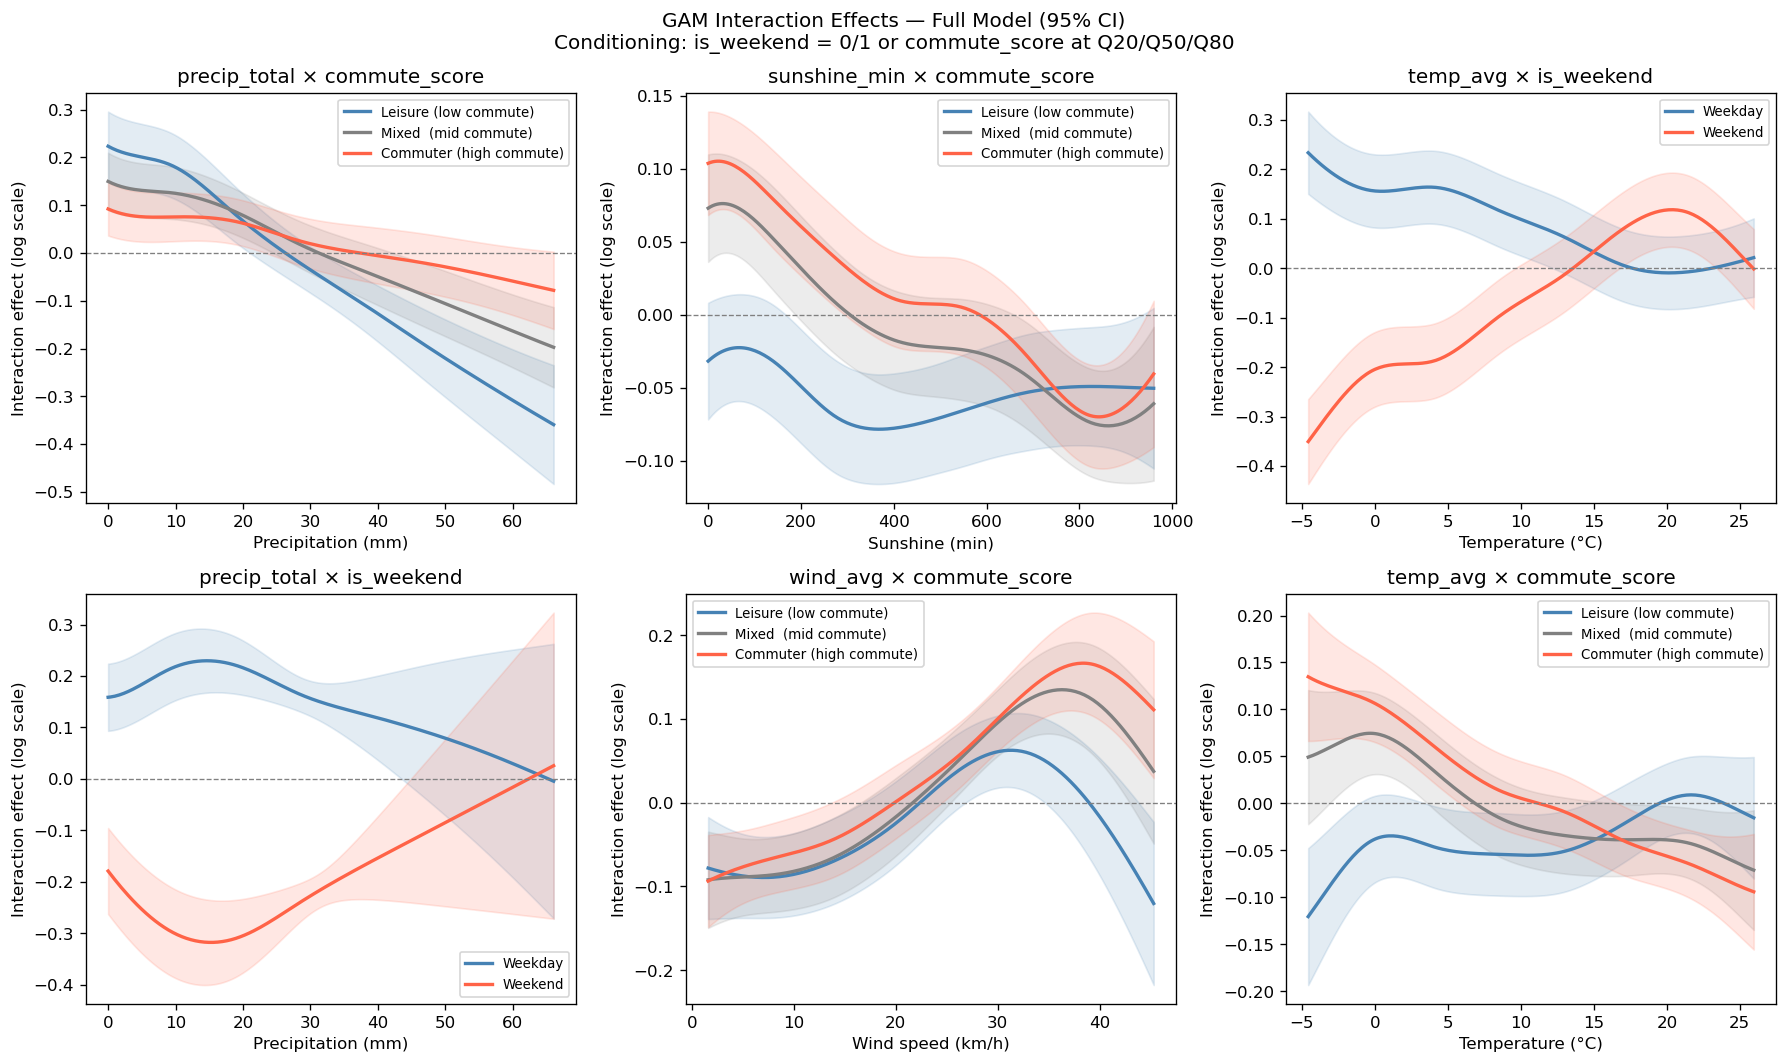

08_gam_interaction_effects_interactions.png saved.


In [15]:
# ── helper: inverse-transform a single feature column ─────────────────
def inv_feat(X_std, feat_idx, scaler_obj):
    pos   = continuous_idx.index(feat_idx)
    dummy = np.zeros((len(X_std), len(continuous_idx)))
    dummy[:, pos] = X_std[:, feat_idx]
    return scaler_obj.inverse_transform(dummy)[:, pos]

N_PTS     = 200
N_FEAT    = X_train_s.shape[1]
MONTH_IDX = ALL_FEATURES.index("month")

# commute_score conditioning levels from full model training data
CS_LOW = float(np.quantile(X_train_s[:, 14], 0.20))
CS_MID = float(np.quantile(X_train_s[:, 14], 0.50))
CS_HI  = float(np.quantile(X_train_s[:, 14], 0.80))

# ── interaction term definitions ───────────────────────────────────────
TE_PLOT_DEFS = [
    (15,  1, "Precipitation (mm)",  14, "continuous", "precip_total × commute_score"),
    (16,  3, "Sunshine (min)",      14, "continuous", "sunshine_min × commute_score"),
    (17,  0, "Temperature (°C)",    10, "binary",     "temp_avg × is_weekend"),
    (18,  1, "Precipitation (mm)",  10, "binary",     "precip_total × is_weekend"),
    (19,  2, "Wind speed (km/h)",   14, "continuous", "wind_avg × commute_score"),
    (20,  0, "Temperature (°C)",    14, "continuous", "temp_avg × commute_score"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (term_idx, feat_a, xlabel, feat_b, feat_b_type, title) in zip(
        axes.flatten(), TE_PLOT_DEFS):

    X_base = np.zeros((N_PTS, N_FEAT))
    X_base[:, MONTH_IDX] = 6
    X_base[:, feat_a] = np.linspace(
        float(X_train_s[:, feat_a].min()),
        float(X_train_s[:, feat_a].max()), N_PTS)
    x_orig = inv_feat(X_base, feat_a, scaler)

    levels = (
        [(0, "Weekday", "steelblue"), (1, "Weekend", "tomato")]
        if feat_b_type == "binary" else
        [(CS_LOW, "Leisure (low commute)",   "steelblue"),
         (CS_MID, "Mixed  (mid commute)",    "gray"),
         (CS_HI,  "Commuter (high commute)", "tomato")]
    )

    for val, lbl, color in levels:
        XX = X_base.copy()
        XX[:, feat_b] = val
        pdep, ci = gam_full.partial_dependence(term=term_idx, X=XX, width=0.95)
        ax.plot(x_orig, pdep, label=lbl, color=color, linewidth=2)
        ax.fill_between(x_orig, ci[:, 0], ci[:, 1], alpha=0.15, color=color)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Interaction effect (log scale)")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(
    "GAM Interaction Effects — Full Model (95% CI)\n"
    "Conditioning: is_weekend = 0/1 or commute_score at Q20/Q50/Q80",
    fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / "08_gam_interaction_effects_interactions.png", dpi=150)
plt.show()
print("08_gam_interaction_effects_interactions.png saved.")


## 8. Weather-Normalized Cycling Index

Normalized cycling index saved.


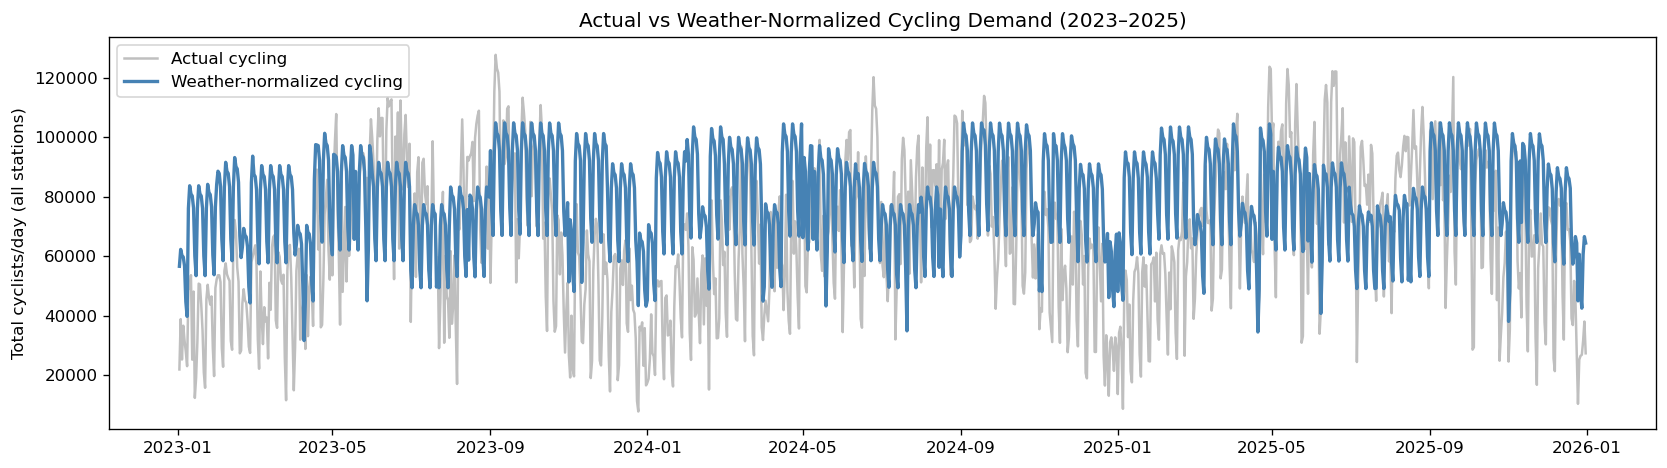

08_normalized_vs_actual saved.


In [16]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
    "wind_avg_lag1"     : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

cols_needed = ALL_FEATURES + ["site_offset"]
panel_norm_clean = panel_norm[cols_needed + ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]].dropna()

X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(float)
for feat, val_ref in ref_weather.items():
    idx = ALL_FEATURES.index(feat)
    X_norm[:, idx] = val_ref

X_norm_s = X_norm.copy()
X_norm_s[:, continuous_idx] = scaler.transform(X_norm[:, continuous_idx])

y_adj_pred = gam_full.predict(X_norm_s)
offset     = panel_norm_clean["site_offset"].values
panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = np.clip(np.expm1(y_adj_pred + offset), 0, None)

panel_norm_clean[["site ID", "naam", "date", "aantal",
                   "normalized_count", "site_type",
                   "day_type", "season"]].to_parquet(
    PROCESSED / "normalized_cycling.parquet", index=False
)
print("Normalized cycling index saved.")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2, label="Weather-normalized cycling")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023\u20132025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08_normalized_vs_actual_interactions.png", dpi=150)
plt.show()
print("08_normalized_vs_actual saved.")


**1. Weather is the primary driver of seasonal fluctuations**

The seasonal amplitude of the actual cycling curve (grey) is far larger than the normalized curve (blue). During winter months, actual counts fall substantially below normalized levels, indicating that the winter cycling drop is largely attributable to adverse weather conditions (low temperatures, rain) rather than a genuine collapse in underlying demand.

**2. Calendar effects are fully preserved after normalization**

The blue curve retains a clear high-frequency oscillation throughout the entire period. This reflects the day-of-week effect (weekend peaks vs. weekday troughs). Since normalization only removes weather variation, calendar signals remain intact in the normalized counts — consistent with model expectations.

**3. No evident growth trend in baseline cycling demand across three years**

The normalized curve holds a broadly stable mid-range level (~60,000–90,000 cyclists/day across all stations) from 2023 through 2025, with no sustained upward trend. Under the assumption of identical reference weather conditions, the underlying cycling demand at AWV stations appears structurally stable over this period.

**4. Favourable summers generate a weather bonus above the reference level**
   
During spring–summer 2023 and summer 2024, the actual curve periodically exceeds the normalized curve, indicating that real weather conditions on those days were better than the reference scenario (15 °C, 0 mm rain, 300 min sunshine, 10 km/h wind), producing additional weather-driven cycling above the modelled baseline.

**5. The late-2024 / early-2025 dip is weather-driven, not structural**
   
A pronounced trough is visible in the actual curve around December 2024 – January 2025, while the normalized curve remains relatively flat over the same period. This confirms the dip was caused by an episode of severe weather (cold spell or persistent rain) rather than a structural decline in cycling demand.

## 9. Weather Effect Magnitudes

In [17]:
# Extract per-row site offsets aligned with each training X matrix
def get_offsets(df, features):
    cols = features + ["aantal", "site_offset"]
    return df[cols].dropna()["site_offset"].values

offsets_full = get_offsets(train,   ALL_FEATURES)
offsets_c    = get_offsets(train_c, ALL_FEATURES)
offsets_l    = get_offsets(train_l, ALL_FEATURES)
offsets_m    = get_offsets(train_m, ALL_FEATURES)
def weather_effect_ame(gam, X_scaled, offsets, feature_idx, bad_val, ref_val, scaler_obj):
    """
    Average Marginal Effect: for every training row, change one weather variable
    from ref_val to bad_val (all else fixed), then average the % change in predicted count.
    """
    X_bad = X_scaled.copy()
    X_ref = X_scaled.copy()
    if feature_idx in continuous_idx:
        pos = continuous_idx.index(feature_idx)
        X_bad[:, feature_idx] = (bad_val - scaler_obj.mean_[pos]) / scaler_obj.scale_[pos]
        X_ref[:, feature_idx] = (ref_val - scaler_obj.mean_[pos]) / scaler_obj.scale_[pos]
    else:
        X_bad[:, feature_idx] = bad_val
        X_ref[:, feature_idx] = ref_val
    y_bad = np.expm1(gam.predict(X_bad) + offsets)
    y_ref = np.expm1(gam.predict(X_ref) + offsets)
    pct_changes = (y_bad - y_ref) / np.where(y_ref > 0, y_ref, np.nan) * 100
    return np.nanmean(pct_changes)

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0°C vs 15°C)",      0,  0.0,  15.0),
    ("Cool day (8°C vs 15°C)",      0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("=" * 80)
print("GAM WEATHER EFFECT SIZES  (Average Marginal Effect, train 2023–2024)")
print("=" * 80)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8} | {'Mixed':>7}")
print("-" * 80)
for label, feat_idx, bad_val, ref_val in comparisons:
    eff_full = weather_effect_ame(gam_full,     X_train_s,  offsets_full, feat_idx, bad_val, ref_val, scaler)
    eff_c    = weather_effect_ame(gam_commuter, X_train_cs, offsets_c,    feat_idx, bad_val, ref_val, scaler_c)
    eff_l    = weather_effect_ame(gam_leisure,  X_train_ls, offsets_l,    feat_idx, bad_val, ref_val, scaler_l)
    eff_m    = weather_effect_ame(gam_mixed,    X_train_ms, offsets_m,    feat_idx, bad_val, ref_val, scaler_m)
    print(f"{label:<35} | {eff_full:>6.1f}% | {eff_c:>8.1f}% | {eff_l:>7.1f}% | {eff_m:>7.1f}%")
print()
print("Each estimate is the mean % change across all training observations")
print("when one weather variable changes, all other variables held fixed.")

GAM WEATHER EFFECT SIZES  (Average Marginal Effect, train 2023–2024)
Condition                           |    Full |  Commuter |  Leisure |   Mixed
--------------------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -35.8% |    -31.2% |   -41.1% |   -36.9%
Light rain (2mm vs 0mm)             |  -11.0% |     -8.8% |   -13.9% |    -9.6%
Cold day (0°C vs 15°C)              |  -36.7% |    -32.4% |   -45.5% |   -36.2%
Cool day (8°C vs 15°C)              |  -17.8% |    -14.8% |   -25.2% |   -16.1%
Strong wind (40 vs 10 km/h)         |  -57.6% |    -55.3% |   -65.4% |   -50.1%
No sunshine (0 vs 300 min)          |  -15.1% |    -12.3% |   -18.6% |   -13.4%

Each estimate is the mean % change across all training observations
when one weather variable changes, all other variables held fixed.


## 10. Save Models

In [22]:
#serialize the fitted GAM models and related objects for future use 
models = {
    "gam_full"     : gam_full,
    "gam_commuter" : gam_commuter,
    "gam_leisure"  : gam_leisure,
    "gam_mixed"    : gam_mixed,
    "scaler"       : scaler,
    "scaler_c"     : scaler_c,
    "scaler_l"     : scaler_l,
    "scaler_m"     : scaler_m,
    "site_log_mean": site_log_mean,
    "continuous_idx": continuous_idx,
    "ALL_FEATURES" : ALL_FEATURES,
}
with open(PROCESSED / "gam_models_interactions.pkl", "wb") as fh: 
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'gam_models_interactions.pkl'}")


Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/gam_models_interactions.pkl


## 10. Final Summary

In [23]:
heavy_rain_full = weather_effect_ame(gam_full, X_train_s, offsets_full, 1, 20.0,  0.0, scaler)
cold_day_full   = weather_effect_ame(gam_full, X_train_s, offsets_full, 0,  0.0, 15.0, scaler)
strong_wind_full= weather_effect_ame(gam_full, X_train_s, offsets_full, 2, 40.0, 10.0, scaler)

print("=" * 52)
print("GAM MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2023–2024 ({len(y_train_adj):,} observations)")
print(f"Test period     : 2025     ({len(y_test_adj):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full GAM     : MAE={test_mae_full:.1f}, R²={test_r2_full:.3f}")
print(f"  Commuter GAM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure GAM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print(f"  Mixed GAM    : MAE={mae_m:.1f}, R²={r2_m:.3f}")
print()
print("Key weather effects on cycling demand (full model, AME):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0°C)    : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")

GAM MODELLING SUMMARY
Training period : 2023–2024 (95,400 observations)
Test period     : 2025     (47,842 observations)

Model performance (test set):
  Full GAM     : MAE=131.1, R²=0.843
  Commuter GAM : MAE=118.3, R²=0.908
  Leisure GAM  : MAE=143.6, R²=0.717
  Mixed GAM    : MAE=123.8, R²=0.806

Key weather effects on cycling demand (full model, AME):
  Heavy rain (20mm) : -35.8%
  Cold day (0°C)    : -36.7%
  Strong wind       : -57.6%
